This notebook accompanies the paper "Neural Prediction Decorrelation Reveals that Adversarial Robustness Improves DNN Prediction Accuracy across the Entire Human Auditory Cortex" by David Skrill, Jenelle Feather, and Sam Norman-Haignere. This relatively minimal notebook is intended to get your feet wet with stimulus synthesis and prediction decorrelation. The procedure shown here is a simplified version of what is described in the paper, not a replication of the results. For details on the full procedure, see the paper or the full code repository.

Notebook compute requirements:


- 64GB RAM
- 1-2 GPUs (~80 GB VRAM total)

It is possible to run the notebook using only CPU, but this will take a long time.

You will also need a Python environment with the packages listed in the cell below. Uncomment the cell and run it to install the packages, or create your own environment with the packages you need.

In [8]:
!pip install matplotlib numpy torch einops librosa himalaya transformers tqdm scipy git+https://github.com/jenellefeather/chcochleagram.git

  Cloning https://github.com/jenellefeather/chcochleagram.git to /tmp/pip-req-build-8qeliknf
  Running command git clone --filter=blob:none --quiet https://github.com/jenellefeather/chcochleagram.git /tmp/pip-req-build-8qeliknf
  Resolved https://github.com/jenellefeather/chcochleagram.git to commit 731387778e40ee0298fdb13ac72789802f8e3cbb
  Preparing metadata (setup.py) ... done


In [9]:
import os
import matplotlib.pyplot as plt
import pickle
import numpy as np
import torch
import einops
import librosa
import himalaya
from io import BytesIO
import urllib.request
from tqdm.auto import tqdm, trange
from scipy.stats import pearsonr
import torch
from transformers import AutoConfig, AutoModelForAudioClassification

himalaya.backend.set_backend("torch")

# Set up device(s)
# If you have one large GPU (e.g., H100), you can use that for both models.
# If you have two smaller GPUs, you can put one model on each
# If you are running on CPU only, change both cuda:x to cpu.
device1=torch.device("cuda")
device2=torch.device("cuda")

### Instantiate models

Download and instantiate the standard and robust variants of the CochResNet50 model. These have been formatted to follow the conventions of the Hugging Face `transformers` library. See the paper and [Feather et al. (2023)](https://www.nature.com/articles/s41593-023-01442-0) for details on the model architecture.

In [10]:
# config = AutoConfig.from_pretrained("dskrill/cochresnet50",trust_remote_code=True)
robust = AutoModelForAudioClassification.from_pretrained(
    "dskrill/cochresnet50",
    low_cpu_mem_usage=False,
    trust_remote_code=True,
).to(device1)

standard = AutoModelForAudioClassification.from_pretrained(
    "dskrill/cochresnet50",
    low_cpu_mem_usage=False,
    trust_remote_code=True,
    revision="standard",
).to(device2)


Loading weights:   0%|          | 0/323 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/323 [00:00<?, ?it/s]

### Load data

The data file accompanying this notebook, `experiment_1_2_data.npz`, contains the preprocessed data from experiments 1 ([Norman-Haignere et al., 2015](https://www.sciencedirect.com/science/article/pii/S0896627315010715?via%3Dihub)) and 2 ([Boebinger et al., 2023](https://journals.physiology.org/doi/full/10.1152/jn.00588.2020)). It contains the following keys:

In [11]:
url = f"https://rochester.box.com/shared/static/argx30adobg3ge33na0acbli64v3vjle.npz"
response = urllib.request.urlopen(url)
data = np.load(BytesIO(response.read()),allow_pickle=True)

for key in data.keys():
    print(f"key: {key}, shape: {data[key].shape}")

key: experiment_1_data, shape: (165, 23160)
key: experiment_2_data, shape: (165, 46320)
key: stim_names, shape: (165,)
key: sounds, shape: (165, 40000)


`experiment_1_data` and `experiment_2_data` are (stimulus, voxel) responses matrices for experiments 1 and 2, respectively. `stim_names` is an array of stimulus names, and `sounds` is a (stimulus, samples) matrix of stimulus waveforms. The ordering of the stimuli is the same for all arrays, and was chosen so that the 165 sounds can be divided into 3 groups of 55 stimuli, each with similar distribution  of sound types.

In [12]:
D1 = data['experiment_1_data']
D2 = data['experiment_2_data']
stim_names = data['stim_names']
S = data['sounds']

In [13]:
# How David created the data (to be deleted):

# natsounds = pickle.load(open("natsounds.pkl", "rb"))
# natsounds['D'] = natsounds['D'] - natsounds['D'].mean(axis=-1,keepdims=True)
# natsounds['D'] = natsounds['D'] / natsounds['D'].std(axis=-1,keepdims=True)
# D1 = natsounds['D'][...,:10]
# D2 = natsounds['D'][...,10:]
# D1 = einops.reduce(D1,
#                 'stim voxel rep subj -> stim (subj voxel)',np.nanmean)
# D2 = einops.reduce(D2,
#                 'stim voxel rep subj -> stim (subj voxel)',np.nanmean)
# S = np.array([
#     rms_normalize(torch.from_numpy(librosa.load(
#         os.path.join(stimuli_dir, stim_name+".wav"), sr=20000)[0]),rms_level=0.1,dim=0).numpy() \
#         for stim_name in natsounds['stim_names']
#     ])

# np.savez("experiment_1_2_data.npz",experiment_1_data=D1,experiment_2_data=D2,stim_names=natsounds['stim_names'],sounds=S)

### Fit encoding models

We demonstrate one of the basic claims of the paper: that encoding models often make similar predictions for natural sounds. To do so, we:

1. Pipe our matrix of stimulus waveforms through the robust and standard models, and store the activations.

2. Extract activations from an intermediate layer, reshape to a (stimulus, feature) matrix, and reduce the features to 50 principal components.
    
3. Fit a ridge regression model to predict the brain responses from the activations.

Following the structure of the paper, we fit step 3 using the first 55 stimuli only, and evaluate on a different set of 55 stimuli.

Step 1: Input the stimulus waveforms to the robust and standard models, and store the activations.

In [14]:
S_ = torch.from_numpy(S)
with torch.no_grad():
  robust_out = robust(S_.to(device1),output_hidden_states=True)
  standard_out = standard(S_.to(device2),output_hidden_states=True)

2. Extract activations from an intermediate layer, reshape to a (stimulus, feature) matrix, and reduce the features to 50 principal components.

In [15]:
selected_layer_idx = 7 #layer3

def reshape_activations(activations):
    return activations.reshape(activations.shape[0],-1)

# Define a truncated SVD class to reduce the number of features
# This torch-only implementation allows us to track gradients through the SVD
# The `transform` method projects a new matrix X onto the reduced space (X@self.v.T)
class TruncatedSVD:
    def __init__(self,n_components=20):
        self.n_components = n_components
    def fit(self,X):
        u,s,v = torch.linalg.svd(X,full_matrices=False)
        self.u = u[...,:self.n_components]
        self.s = s[...,:self.n_components]
        self.v = v[...,:self.n_components,:]
    def transform(self,X):
        return X@self.v.T
    def fit_transform(self,X):
        self.fit(X)
        return self.transform(X)


robust_X = reshape_activations(robust_out.hidden_states[selected_layer_idx])
standard_X = reshape_activations(standard_out.hidden_states[selected_layer_idx])
robust_svd = TruncatedSVD(n_components=50)
standard_svd = TruncatedSVD(n_components=50)
robust_X = robust_svd.fit_transform(robust_X)
standard_X = standard_svd.fit_transform(standard_X)
robust_X.shape,standard_X.shape

(torch.Size([165, 50]), torch.Size([165, 50]))

3. Fit a ridge regression model to predict the brain responses from the activations.

In [16]:
# Partition the data into training, validation, and test sets
# The ordering of the stimuli is such that we can just slice sets of 55 stimuli
D1_train = torch.from_numpy(D1[:55])
D2_train = torch.from_numpy(D2[:55])
D1_val = torch.from_numpy(D1[55:110])
D2_val = torch.from_numpy(D2[55:110])
D1_test = torch.from_numpy(D1[110:])
D2_test = torch.from_numpy(D2[110:])


In [17]:
ridge_robust = himalaya.ridge.RidgeCV(alphas=np.logspace(-5,5,40),fit_intercept=True)
ridge_standard = himalaya.ridge.RidgeCV(alphas=np.logspace(-5,5,40),fit_intercept=True)

ridge_robust.fit(
    robust_X[:55], # Use "training set" (i.e., first 55 sounds) only
    D1_train.to(device1)
)
ridge_standard.fit(
    standard_X[:55],
    D1_train.to(device1)
)

# Define a simple class to store the model coefficients and intercept
# This is used to make predictions from the model while allowing us to track gradients
class myRidge():
    def __init__(self,coefs,intercept):
        self.coefs = coefs
        self.intercept = intercept
        self.device = 'cpu'
    def predict(self,X):
        return X@self.coefs + self.intercept
    def from_RidgeCV(ridge):
        return myRidge(ridge.coef_,ridge.intercept_)
    def to(self,device):
        self.device = device
        self.coefs = self.coefs.to(device)
        self.intercept = self.intercept.to(device)
        return self

ridge_robust = myRidge.from_RidgeCV(ridge_robust).to(device1)
ridge_standard = myRidge.from_RidgeCV(ridge_standard).to(device2)

### Evaluation on natural sounds

Having fit robust and standard encoding models on the first 55 stimuli, we can now evaluate their performance on the validation set of 55 stimuli.

In [18]:
D1_val_preds_robust = ridge_robust.predict(robust_X[55:110].to(device1))
D1_val_preds_standard = ridge_standard.predict(standard_X[55:110].to(device2))

def corr(X,Y):
    # Correlates two tensors columnwise
    # i.e., if X is (stimulus, voxel) and Y is (stimulus, voxel),
    # it will return a (voxel,) vector of correlations between X and Y,
    # evaluated over stimuli for each voxel.
    return pearsonr(X.numpy(force=True),Y.numpy(force=True))[0]

# Robust prediction accuracy
robust_pred_acc = corr(D1_val_preds_robust,D1_val)
# Standard prediction accuracy
standard_pred_acc = corr(D1_val_preds_standard,D1_val)
# Correlation between robust and standard predictions
corrs_between_preds = corr(D1_val_preds_robust,D1_val_preds_standard)

Compare the prediction accuracy and correlation between predictions of the robust and standard models:

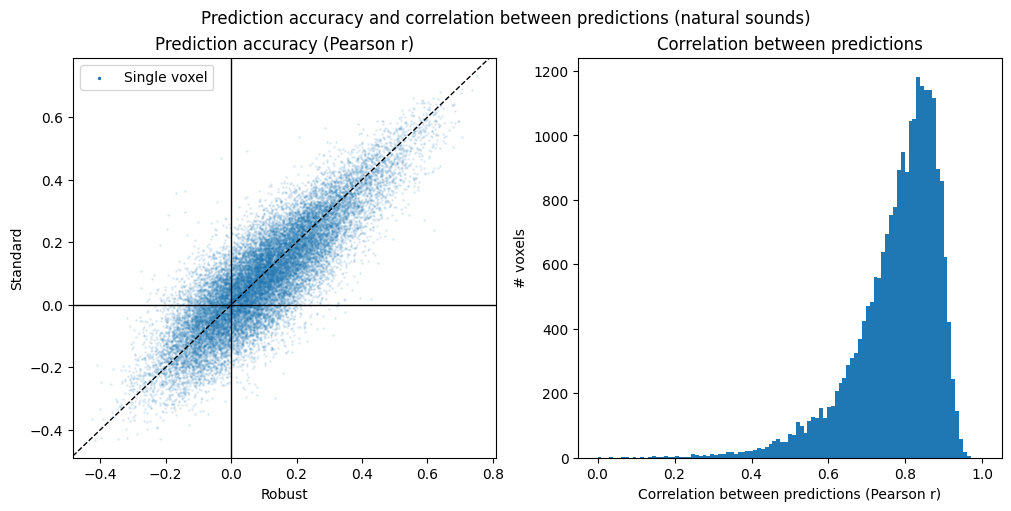

In [19]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

fig,axes = plt.subplots(1,2,layout='constrained',figsize=(10,5))

bins = np.linspace(0,1,100)
axes[0].scatter([],[],label="Single voxel",color="tab:blue",s=2)
axes[0].legend()
axes[0].axline([0,0],slope=1,color='k',linewidth=1,linestyle='--')
axes[0].axvline(0,color='k',linewidth=1)
axes[0].axhline(0,color='k',linewidth=1)
axes[0].scatter(robust_pred_acc,standard_pred_acc,s=1,alpha=.1)
axes[1].hist(corrs_between_preds,bins=bins)

axes[0].set_xlabel('Robust');axes[0].set_ylabel('Standard')
axes[0].set_title('Prediction accuracy (Pearson r)')
axes[1].set_xlabel('Correlation between predictions (Pearson r)');axes[1].set_ylabel('# voxels')
axes[1].set_title('Correlation between predictions')

fig.suptitle('Prediction accuracy and correlation between predictions (natural sounds)')
plt.show()


This demonstrates that the robust and standard models make similar predictions for natural sounds. Next, we will synthesize stimuli for which the robust and standard models make different predictions.

### Synthesis

We will use a simple optimization procedure to synthesize stimuli that drive the robust and standard models to make different predictions. The algorithm here optimizes the stimulus waveforms directly to minimize the columnwise covariance model  predictions, while maintaining approximately unit variance. Note that this is a simplified version of the procedure used in the paper.

In [20]:
# Define an efficient covariance function that allows gradients to be backpropagated
def mycov(A, B, axis=-2, device=None):
    """
    Compute covariance between A and B along specified axis.

    Handles both numpy arrays and torch tensors. Returns the same type as inputs.

    Args:
        A: First array/tensor (observations x features)
        B: Second array/tensor (observations x features)
        axis: Axis along which to compute covariance (default: -2)
        device: Torch device to use for computation (optional)

    Returns:
        Covariance values (same type as input)
    """
    # Move to device if specified
    if device is not None:
        A = A.to(device)
        B = B.to(device)

    # Compute covariance
    A_ = A - torch.nanmean(A, axis=axis, keepdims=True)
    B_ = B - torch.nanmean(B, axis=axis, keepdims=True)
    C = torch.nanmean(A_ * B_, axis=axis)

    return C

# The DNN models expect RMS-normalized input waveforms
def rms_normalize(waveform, rms_level=0.1, dim=1):
    """
    RMS normalize waveform to specified level.

    Unified function that handles both batch and single waveforms.

    Args:
        waveform: Audio waveform tensor (..., samples) or (batch, samples)
        rms_level: Target RMS level (default: 0.1)
        dim: Dimension along which to compute RMS (default: 1 for batch dim)

    Returns:
        RMS-normalized waveform
    """
    out = waveform - waveform.mean(dim=dim, keepdim=True)
    waveform_rms = torch.sqrt(torch.mean(torch.pow(out, 2), dim=dim, keepdim=True))
    out = out * rms_level / waveform_rms
    return out

In [21]:
device1.type

'cuda'

In [22]:
def synthesize(
    model1,
    model2,
    n_stimuli: int = 30,
    base_lr: float = 5e-3,
    max_steps: int = 1000,
    t_0: int = 200,
    t_mult: int = 1,
    eta_min: float = 1e-5,
):
    """Synthesize input waveforms that jointly drive two models.

    This function optimizes a batch of input waveforms so that the predicted
    brain responses from `model1` and `model2` have low covariance and
    approximately unit variance across voxels. The optimization is performed
    with Adam and a cosine annealing with warm restarts learning rate schedule
    (`torch.optim.lr_scheduler.CosineAnnealingWarmRestarts`).

    Parameters
    ----------
    model1 : torch.nn.Module
        First audio model (`robust` in this notebook) supporting
        `output_hidden_states=True`.
    model2 : torch.nn.Module
        Second audio model (`standard` in this notebook) supporting
        `output_hidden_states=True`.
    n_stimuli : int, optional
        Number of stimuli (independent waveforms) to optimize, by default 30.
    base_lr : float, optional
        Initial learning rate for the Adam optimizer, by default 1e-3.
    max_steps : int, optional
        Number of optimization iterations (and scheduler steps), by default 1000.
    t_0 : int, optional
        Number of steps for the first cosine cycle (`T_0` in
        `CosineAnnealingWarmRestarts`), by default 100.
    t_mult : int, optional
        Multiplicative factor for increasing cycle length after each restart
        (`T_mult` in `CosineAnnealingWarmRestarts`), by default 2.
    eta_min : float, optional
        Minimum learning rate within each cosine cycle, by default 1e-5.

    Returns
    -------
    np.ndarray
        Array of shape `(n_stimuli, 40000)` containing the optimized waveforms
        on CPU as a NumPy array.

    Usage
    -----
    >>> synthesized = synthesize(robust, standard)
    >>> synthesized.shape  # (n_stimuli, 40000)
    """
    S_ = torch.randn(n_stimuli, 40000, requires_grad=True, device=device1)
    opt = torch.optim.Adam([S_], lr=base_lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        opt,
        T_0=t_0,
        T_mult=t_mult,
        eta_min=eta_min,
    )

    for step in trange(max_steps):
        opt.zero_grad()
        S_norm = rms_normalize(S_)
        with torch.amp.autocast(device1.type):
             # Input stimulus to the models, and store the activations
            robust_activations = model1(
                S_norm.to(device1,non_blocking=True), output_hidden_states=True
            ).hidden_states[selected_layer_idx]
            standard_activations = model2(
                S_norm.to(device2,non_blocking=True), output_hidden_states=True
            ).hidden_states[selected_layer_idx]

            # Reshape and reduce the activations to 50 principal components
            robust_activations_reshaped = reshape_activations(robust_activations)
            robust_activations_trunc = robust_svd.transform(robust_activations_reshaped)
            standard_activations_reshaped = reshape_activations(standard_activations)
            standard_activations_trunc = standard_svd.transform(
                standard_activations_reshaped
            )

            # Predict the brain responses from the activations
            preds_robust = ridge_robust.predict(robust_activations_trunc).to(device1)
            preds_standard = ridge_standard.predict(standard_activations_trunc).to(device1)

            # Compute the loss
            if device1.type == "cuda":
              torch.cuda.synchronize(device1);torch.cuda.synchronize(device2)
            loss = (
                torch.linalg.norm(
                    mycov(preds_robust, preds_standard, 0)
                )
                ** 2
            )
            loss += torch.linalg.norm(
                preds_robust.var(0) - torch.ones_like(preds_robust.var(0))
            ).to(device1)
            loss += torch.linalg.norm(
                preds_standard.var(0) - torch.ones_like(preds_standard.var(0))
            ).to(device1)
        # Backpropagate the loss
        loss.backward()
        # Update the optimizer step
        opt.step()
        # Update the learning rate scheduler
        scheduler.step(step)

        if step % 10 == 0:
            current_lr = opt.param_groups[0]["lr"]
            print(f"step={step}, loss={loss.item():.6f}, lr={current_lr:.6e}")

    return S_norm.detach().cpu().numpy()


synthesized = synthesize(robust, standard)

  0%|          | 0/1000 [00:00<?, ?it/s]

step=0, loss=304.334534, lr=5.000000e-03
step=10, loss=303.558533, lr=4.969282e-03
step=20, loss=302.751251, lr=4.877886e-03
step=30, loss=302.041260, lr=4.728061e-03
step=40, loss=301.395081, lr=4.523497e-03
step=50, loss=300.829834, lr=4.269231e-03
step=60, loss=300.332947, lr=3.971524e-03
step=70, loss=299.898560, lr=3.637706e-03
step=80, loss=299.531372, lr=3.275997e-03
step=90, loss=299.223694, lr=2.895304e-03
step=100, loss=298.966797, lr=2.505000e-03
step=110, loss=298.754028, lr=2.114696e-03
step=120, loss=298.579590, lr=1.734003e-03
step=130, loss=298.441223, lr=1.372294e-03
step=140, loss=298.335083, lr=1.038476e-03
step=150, loss=298.257111, lr=7.407686e-04
step=160, loss=298.202728, lr=4.865026e-04
step=170, loss=298.168152, lr=2.819387e-04
step=180, loss=298.148468, lr=1.321140e-04
step=190, loss=298.140289, lr=4.071759e-05
step=200, loss=298.138367, lr=5.000000e-03
step=210, loss=297.801514, lr=4.969282e-03
step=220, loss=297.457031, lr=4.877886e-03
step=230, loss=297.135

Let's listen to the synthesized stimuli!

In [23]:
from IPython.display import Audio
Audio(np.concatenate(synthesized,axis=0),rate=20000)


### Do the synthesized sounds decorrelate the model predictions?

Following the logic of the paper, we test is the synthesized stimuli decorrelate the model predictions for new participants. We do this using encoding models fit to the data from experiment 2 (noting that only data from experiment 1, not 2, were used to fit the models).

We fit a ridge regression model to predict the brain responses from the activations for the new participants, and evaluate the correlation between the predictions of the robust and standard models.


In [24]:
ridge_robust_experiment2 = himalaya.ridge.RidgeCV(alphas=np.logspace(-5,5,40),fit_intercept=True)
ridge_standard_experiment2 = himalaya.ridge.RidgeCV(alphas=np.logspace(-5,5,40),fit_intercept=True)

ridge_robust_experiment2.fit(
    robust_X[:55],
    D2_train.to(device1)
)
ridge_standard_experiment2.fit(
    standard_X[:55],
    D2_train.to(device2)
)

RidgeCV(alphas=array([1.00000000e-05, 1.80472177e-05, 3.25702066e-05, 5.87801607e-05,
       1.06081836e-04, 1.91448198e-04, 3.45510729e-04, 6.23550734e-04,
       1.12533558e-03, 2.03091762e-03, 3.66524124e-03, 6.61474064e-03,
       1.19377664e-02, 2.15443469e-02, 3.88815518e-02, 7.01703829e-02,
       1.26638017e-01, 2.28546386e-01, 4.12462638e-01, 7.44380301e-01,
       1.34339933e+00, 2.42446202e+00, 4.37547938e+00, 7.89652287e+00,
       1.42510267e+01, 2.57191381e+01, 4.64158883e+01, 8.37677640e+01,
       1.51177507e+02, 2.72833338e+02, 4.92388263e+02, 8.88623816e+02,
       1.60371874e+03, 2.89426612e+03, 5.22334507e+03, 9.42668455e+03,
       1.70125428e+04, 3.07029063e+04, 5.54102033e+04, 1.00000000e+05]),
        fit_intercept=True)

Now, we extract and process activations for the synthesized stimuli, and input them to the new ridge regression models. We compare against the predictions of the robust and standard models on the natural sounds.

In [25]:

robust_synthesized_out = robust(torch.from_numpy(synthesized).to(device1),output_hidden_states=True).hidden_states[selected_layer_idx]
standard_synthesized_out = standard(torch.from_numpy(synthesized).to(device2),output_hidden_states=True).hidden_states[selected_layer_idx]
X_robust_synthesized = reshape_activations(robust_synthesized_out)
X_standard_synthesized = reshape_activations(standard_synthesized_out)
X_robust_synthesized_trunc = robust_svd.transform(X_robust_synthesized)
X_standard_synthesized_trunc = standard_svd.transform(X_standard_synthesized)

ridge_robust_experiment2 = myRidge.from_RidgeCV(ridge_robust_experiment2).to(device1)
ridge_standard_experiment2 = myRidge.from_RidgeCV(ridge_standard_experiment2).to(device2)

D2_val_preds_robust_natural = ridge_robust_experiment2.predict(robust_X[55:110])
D2_val_preds_standard_natural = ridge_standard_experiment2.predict(standard_X[55:110])
D2_val_preds_robust_NPD = ridge_robust_experiment2.predict(X_robust_synthesized_trunc)
D2_val_preds_standard_NPD = ridge_standard_experiment2.predict(X_standard_synthesized_trunc)

corrs_between_preds_natural = corr(D2_val_preds_robust_natural,D2_val_preds_standard_natural)
corrs_between_preds_NPD = corr(D2_val_preds_robust_NPD,D2_val_preds_standard_NPD)

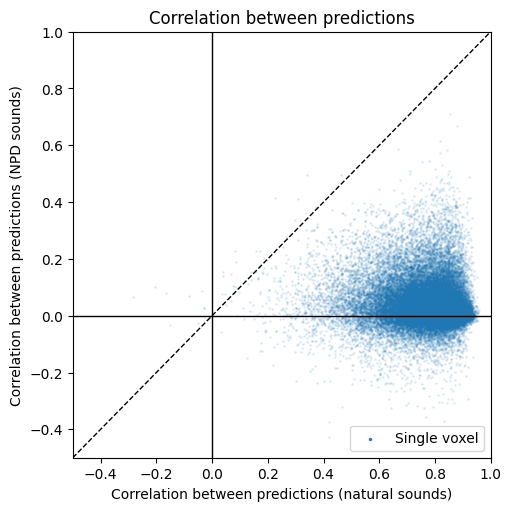

In [26]:
fig,ax = plt.subplots(1,1,figsize=(5,5),layout='constrained')
ax.scatter([],[],s=2,label='Single voxel',color='tab:blue')
ax.scatter(corrs_between_preds_natural,corrs_between_preds_NPD,s=1,alpha=.1,color='tab:blue')
ax.set_xlabel('Correlation between predictions (natural sounds)')
ax.set_ylabel('Correlation between predictions (NPD sounds)')
ax.set_xlim(-.5,1)
ax.set_ylim(-.5,1)
ax.axline([0,0],slope=1,color='k',linewidth=1,linestyle='--')
ax.axvline(0,color='k',linewidth=1)
ax.axhline(0,color='k',linewidth=1)
ax.set_title('Correlation between predictions')
ax.legend()
plt.show()



The plot above shows that the synthesized stimuli do indeed decorrelate the model predictions for new participants!